##### Ссылка на репозиторий и этот ноутбук с файлами: github: https://github.com/randnull/genotec/blob/main/hw_4_phasing_and_ibd.ipynb

Домашнее задание 4

## Для каждой пары геномов найдите IBD сегменты. Можете использовать фазирование и поиск IBD-сегментов. Можете использовать поиск half-IBD сегментов без фазирования.

Будем делать фазирование (разделение на галотипы) и поиск IBD-сегментов. Для этого будем использовать утилиту [beagle](https://faculty.washington.edu/browning/beagle/beagle.html), предварительно переконвертировав данные в формат vcf с помощью plink (также будем использовать карту GRCh37, чтобы перевести bp в cM)

```bash
plink --bfile data/biengi --recode vcf bgz --out input
```

```bash
java -Xmx4g -jar tools/beagle.27Feb25.75f.jar gt=data/input.vcf.gz map=tools/plink.GRCh37.map/plink.allchr.GRCh37.map out=phased_map
```

Теперь сделаем поиск ibd-сегментов с помощью утилиты [hap-ibd](https://github.com/browning-lab/hap-ibd)

```bash
java -Xmx4g -jar tools/hap-ibd.jar gt=data/phased_map.vcf.gz map=tools/plink.GRCh37.map/plink.allchr.GRCh37.map out=ibd_map
```

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm


In [121]:
ibd = pd.read_csv("data/ibd_map.ibd.gz", sep="\t", header=None)

In [122]:
ibd.columns = ["id1", "hap1", "id2", "hap2", "chrom", "start", "end", "cm"]

In [123]:
ibd

,id1,hap1,id2,hap2,chrom,start,end,cm
0,4481622840_R02C01_4481622840_R02C01,2,4481622800_R01C01_4481622800_R01C01,1,1,166944948,167851169,2.283
1,4481622894_R02C02_4481622894_R02C02,1,4481622800_R01C01_4481622800_R01C01,1,1,166944948,167851169,2.283
2,4481622899_R02C02_4481622899_R02C02,1,4481622800_R01C01_4481622800_R01C01,1,1,166944948,167851169,2.283
3,4481622800_R01C01_4481622800_R01C01,1,4257735306_B_4257735306_B,2,1,166944948,167851169,2.283
4,4481622800_R01C01_4481622800_R01C01,1,4247625716_B_4247625716_B,2,1,166944948,167851169,2.283
...,...,...,...,...,...,...,...,...
796642,4461875303_R02C01_4461875303_R02C01,2,4461875834_R02C02_4461875834_R02C02,1,22,43196508,45215256,5.590
796643,4461875653_R01C02_4461875653_R01C02,1,4461875654_R02C01_4461875654_R02C01,1,22,42805839,48211407,13.034
796644,4461875306_R01C01_4461875306_R01C01,1,4461875306_R02C01_4461875306_R02C01,1,22,43120253,49524956,18.696
796645,4461875329_R02C02_4461875329_R02C02,1,4461875330_R02C01_4461875330_R02C01,2,22,43577158,45682591,6.675


Мы видим такой результат:

id первого человека (4461875520_R01C01_4461875520_R01C01), его галотип, id второго, его галотип а дальше идет номер хромосомы, позиция старта и конца и длина совпадающего участка в сМ

## Вычислите среднее количество общей суммы IBD / half-IBD сегментов между популяциями. Визуализируйте в виде Heatmap. 

Для этого возьмем данные по популяциям из изначального файла и смерджим их с полученной выше таблицей

In [124]:
pedind = pd.read_csv("data/biengi/biengi.pedind", sep="\t", header=None)
pedind.columns = ["fam_id", "id", "x", "y", "sex", "population"]
pedind["full_id"] = pedind["fam_id"] + "_" + pedind["id"]
pedind

,fam_id,id,x,y,sex,population,full_id
0,4461875510_R01C01,4461875510_R01C01,0,0,1,Karel,4461875510_R01C01_4461875510_R01C01
1,4461875510_R01C02,4461875510_R01C02,0,0,1,Karel,4461875510_R01C02_4461875510_R01C02
2,4461875510_R02C01,4461875510_R02C01,0,0,1,Karel,4461875510_R02C01_4461875510_R02C01
3,4461875513_R02C02,4461875513_R02C02,0,0,1,Karel,4461875513_R02C02_4461875513_R02C02
4,4461875513_R01C02,4461875513_R01C02,0,0,1,Karel,4461875513_R01C02_4461875513_R01C02
...,...,...,...,...,...,...,...
889,4252441600_B,4252441600_B,0,0,2,Yakut,4252441600_B_4252441600_B
890,4252441601_A,4252441601_A,0,0,2,Yakut,4252441601_A_4252441601_A
891,4252441601_B,4252441601_B,0,0,2,Yakut,4252441601_B_4252441601_B
892,4252441619_A,4252441619_A,0,0,2,Yakut,4252441619_A_4252441619_A


Сгруппируем данные по парам индивидам по длине общей совпадающей части

In [125]:
pop_lookup = pedind[["full_id", "population"]]
pair_sum = ibd.groupby(["id1", "id2"], as_index=False)["cm"].sum()
pair_sum = (
    pair_sum
    .merge(pop_lookup.rename(columns={"full_id": "id1", "population": "id1_population"}), on="id1", how="left")
    .merge(pop_lookup.rename(columns={"full_id": "id2", "population": "id2_population"}), on="id2", how="left")
)
pair_sum


,id1,id2,cm,id1_population,id2_population
0,4159588086_A_4159588086_A,4159588086_B_4159588086_B,9.365,Russian_NSK,Russian_NSK
1,4159588086_A_4159588086_A,4159588297_A_4159588297_A,9.042,Russian_NSK,Russian_NSK
2,4159588086_A_4159588086_A,4159588297_B_4159588297_B,13.076,Russian_NSK,Russian_NSK
3,4159588086_A_4159588086_A,4159588392_A_4159588392_A,7.772,Russian_NSK,Russian_NSK
4,4159588086_A_4159588086_A,4159588392_B_4159588392_B,13.906,Russian_NSK,Russian_NSK
...,...,...,...,...,...
244923,4493906459_R01C02_4493906459_R01C02,4481622897_R02C02_4481622897_R02C02,20.293,Kirgiz,Tuva
244924,4493906459_R01C02_4493906459_R01C02,4481622899_R01C01_4481622899_R01C01,15.638,Kirgiz,Tuva
244925,4493906459_R01C02_4493906459_R01C02,4481622899_R01C02_4481622899_R01C02,26.893,Kirgiz,Tuva
244926,4493906459_R01C02_4493906459_R01C02,4481622899_R02C01_4481622899_R02C01,2.406,Kirgiz,Tuva


In [126]:
pair_sum

,id1,id2,cm,id1_population,id2_population
0,4159588086_A_4159588086_A,4159588086_B_4159588086_B,9.365,Russian_NSK,Russian_NSK
1,4159588086_A_4159588086_A,4159588297_A_4159588297_A,9.042,Russian_NSK,Russian_NSK
2,4159588086_A_4159588086_A,4159588297_B_4159588297_B,13.076,Russian_NSK,Russian_NSK
3,4159588086_A_4159588086_A,4159588392_A_4159588392_A,7.772,Russian_NSK,Russian_NSK
4,4159588086_A_4159588086_A,4159588392_B_4159588392_B,13.906,Russian_NSK,Russian_NSK
...,...,...,...,...,...
244923,4493906459_R01C02_4493906459_R01C02,4481622897_R02C02_4481622897_R02C02,20.293,Kirgiz,Tuva
244924,4493906459_R01C02_4493906459_R01C02,4481622899_R01C01_4481622899_R01C01,15.638,Kirgiz,Tuva
244925,4493906459_R01C02_4493906459_R01C02,4481622899_R01C02_4481622899_R01C02,26.893,Kirgiz,Tuva
244926,4493906459_R01C02_4493906459_R01C02,4481622899_R02C01_4481622899_R02C01,2.406,Kirgiz,Tuva


Как мы видим, осталось только смерджить по популяциям, чтобы получить итоговый результат (только отсортируем их в одном формате, чтобы потом не мучаться с маппингом из-за не верхнетреугольной матрицы)

In [127]:
sort_a = np.minimum(pair_sum["id1_population"], pair_sum["id2_population"])
sort_b = np.maximum(pair_sum["id1_population"], pair_sum["id2_population"])
pair_sum["sort_a"], pair_sum["sort_b"] = sort_a, sort_b
sum_by_pop = pair_sum.groupby(["sort_a", "sort_b"])["cm"].sum().unstack(fill_value=0.0)
sum_by_pop

sort_b,Abkhaz,Adygei,Bashkir,Belarus,Buryat,Chechen,Cherkes,Chinese,Chuvash,Kabardin,...,Moldovan,Mordva,Russian_NSK,Russian_STV,Tatar,Tuva,Udmurt,Ukrainian,Uzbek,Yakut
sort_a,,,,,,,,,,,,,,,,,,,,,
Abkhaz,6468.415,7500.826,1138.574,1544.254,809.289,1348.164,8992.312,51.706,924.397,7909.253,...,1545.495,1766.985,1741.663,1979.564,1718.675,767.086,939.033,1328.601,1132.983,527.648
Adygei,0.000,20668.168,1972.205,2299.478,1307.121,1486.079,13151.695,100.796,1789.419,12072.559,...,2205.620,2540.736,2717.423,2795.444,2385.426,1427.050,1650.457,1978.625,1648.587,984.541
Bashkir,0.000,0.000,40368.031,3536.092,8050.719,862.255,2158.203,491.702,9968.227,2161.610,...,3189.417,4752.032,6355.614,6101.338,8915.277,7630.431,7685.003,3533.249,3337.568,8041.291
Belarus,0.000,0.000,0.000,5252.632,1417.126,1081.828,2604.081,103.075,4889.462,2472.575,...,7509.079,8392.167,10337.507,11071.753,5762.535,1262.546,3508.176,9538.760,2018.292,754.470
Buryat,0.000,0.000,0.000,0.000,140590.181,681.922,2293.652,1444.633,4069.733,1979.390,...,1321.621,2446.298,3440.901,3107.727,3749.654,30018.272,3099.912,1497.812,6997.522,56935.289
Chechen,0.000,0.000,0.000,0.000,0.000,8832.270,2144.982,44.817,849.368,2473.773,...,1127.086,1184.728,1131.335,1172.535,975.995,641.847,896.238,977.601,888.378,534.586
Cherkes,0.000,0.000,0.000,0.000,0.000,0.000,12269.650,150.626,1899.284,14146.544,...,2357.975,2872.150,3098.365,3064.626,2613.336,2055.960,1672.962,2153.864,1807.585,1955.850
Chinese,0.000,0.000,0.000,0.000,0.000,0.000,0.000,370.592,266.880,141.431,...,71.143,162.783,170.153,121.161,234.408,1112.833,190.774,62.600,560.104,1231.592
Chuvash,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,26262.767,2062.579,...,4036.302,6842.074,9894.583,8769.665,15166.061,4691.434,8546.936,5538.625,2833.224,3965.399


По таблице видно, что мы получили матрицу где между популяциями находится общее число ibd-сегментов

Теперь нормируем на размер популяции

Для одинаковых популяций получается:

$count = len_a * (len_a - 1) / 2$ (просто упорядоченные пары)

а для разных их произведение:

$count = len_a * len_b$


In [128]:
populations = sorted(pedind["population"].unique())
sizes = pedind["population"].value_counts().to_dict()

heat = pd.DataFrame(0.0, index=populations, columns=populations, dtype=float)
for a in populations:
    for b in populations:
        x, y = (a, b) if a <= b else (b, a)
        s = sum_by_pop.loc[x, y]
        n = sizes[a] * (sizes[a] - 1) / 2 if a == b else sizes[a] * sizes[b]
        heat.loc[a, b] = s / n

Рисовать будет по лог-шкале, так как данные внутри одной популяции очевидно сильно больше, чем между соседними

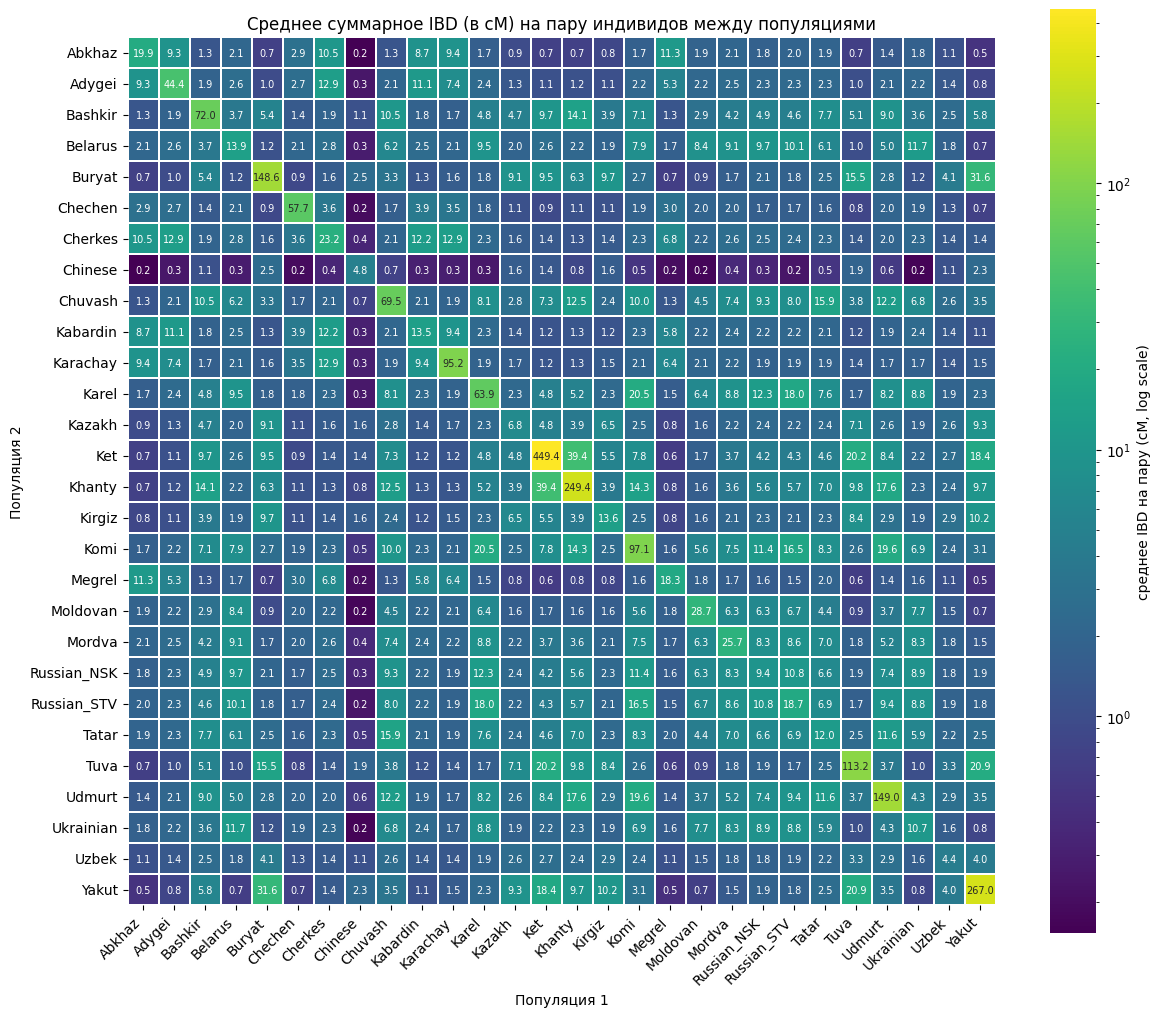

In [129]:
plt.figure(figsize=(14, 12))
sns.heatmap(
    heat,
    cmap="viridis",
    norm=LogNorm(),
    square=True,
    cbar_kws={"label": "среднее IBD на пару (cM, log scale)"},
    linewidths=0.1, linecolor="white",
    annot=True, fmt=".1f", annot_kws={"size": 7},
)
plt.title("Среднее суммарное IBD (в сМ) на пару индивидов между популяциями")
plt.xlabel("Популяция 1")
plt.ylabel("Популяция 2")
plt.xticks(rotation=45, ha="right")
plt.show()

## Проанализируйте и опишите полученный результат. Сравните с PCA

Сначала посмотрим на главную диагональ, где отображены популяции между собой.

Видно, что внутри некоторых популяций среднее число IBD очень велико (Ket, Khanty и Yakut), что может указывать на небольшое число населения в близких областях и/или прохождения популяции через бутылочное горлышко (недавнее).

У Китая, например, среднее число между своей популяцией достаточно низкое - 4.8. Можно предположить, что это из-за огромного размера популяции и большой территории заселения.

Китай также сильнее всего отличается от всех других популяций.

Остальные результаты ожидаемые, где-то связи больше (Bashkir и Khanty), то есть есть общие близкие родственники у многих среди этих популяций. Где-то связи мало - Yakut и Belarus (что тоже логично, так как территория проживания совершенна разная)

Теперь добавим PCA и сравним с ним

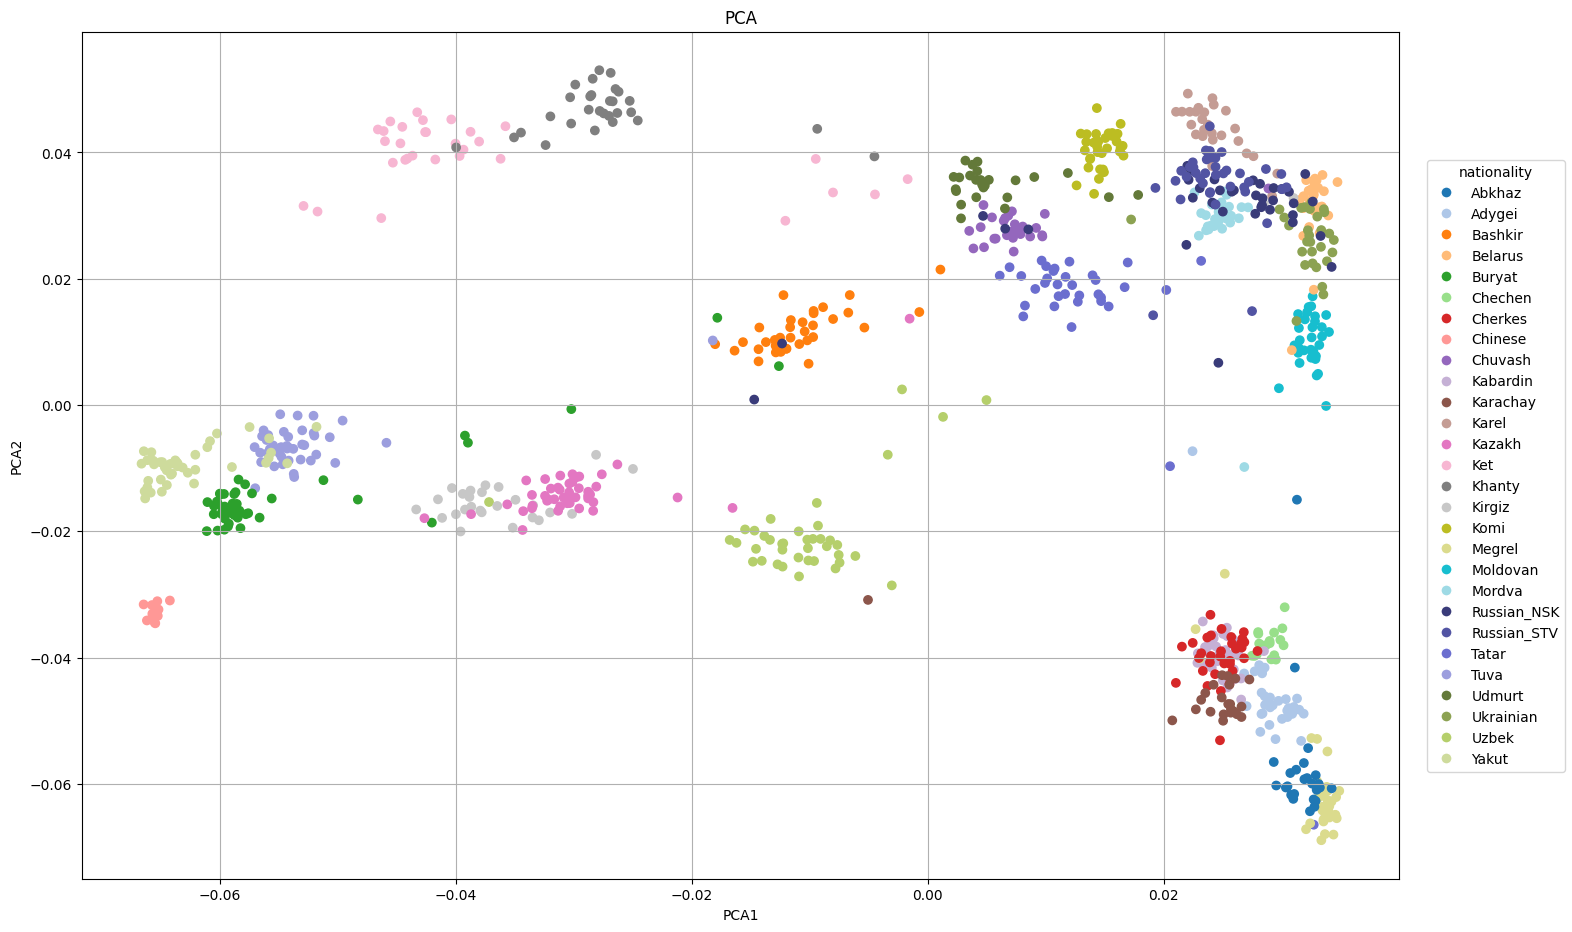

Если смотреть на Китай, то графики не совсем согласуются. Да - Китай отдельно от всех остальных, но внутри самой китайской выборки все индивиды близки друг к другу (проблема интерпритации PCA, последствия ld-prunning).

Якуты близки между собой, и правда, что рядом с Якутами Башкиры и Тувинцы.

В остальном графики средне более-менее согласуются между собой.